# Part 9: GNN From Scratch — GCN for MDM2 Inhibitor Classification

Trains a **Graph Convolutional Network** from scratch on molecular graphs.
No pretrained weights — learns directly from the 645 MDM2 compounds.

**Reference:** Yasir et al., *Future Pharmacology* 2025

**Pipeline:** SMILES → RDKit mol graphs → GCN → 5-fold CV

In [ ]:
!git clone https://github.com/arjunpahi/Natural_MDM2_Inhibitor_Discovery_using_ML.git
%cd Natural_MDM2_Inhibitor_Discovery_using_ML

In [ ]:
!pip install torch-geometric rdkit

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, roc_curve, auc, confusion_matrix
)
from sklearn.utils import shuffle
from rdkit import Chem
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 57
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

## 1. Define GCN Architecture

In [ ]:
class GCN(nn.Module):
    def __init__(self, num_node_features=78, hidden_dim=128, num_classes=2, dropout=0.2):
        super().__init__()
        self.conv1 = GCNConv(num_node_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        self.dropout = dropout
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x, edge_index, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn3(self.conv3(x, edge_index)))
        x = torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim=1)
        return self.classifier(x)

## 2. Load Data + Featurize

In [ ]:
df = pd.read_csv('Part_2/ro5_properties_filtered.csv')
df['y'] = df['bioactivity_class'].apply(lambda x: 1 if x == 'Active' else 0)
print(f"Dataset: {len(df)} compounds")
print(f"Class distribution:\n{df['y'].value_counts()}")

In [ ]:
ATOM_CHOICES = {
    'atomic_num': list(range(1, 101)),
    'degree': [0, 1, 2, 3, 4, 5],
    'formal_charge': [-2, -1, 0, 1, 2, 3],
    'num_hs': [0, 1, 2, 3, 4],
    'hybridization': [
        Chem.rdchem.HybridizationType.SP, Chem.rdchem.HybridizationType.SP2,
        Chem.rdchem.HybridizationType.SP3, Chem.rdchem.HybridizationType.SP3D,
        Chem.rdchem.HybridizationType.SP3D2
    ]
}

def one_hot(val, choices):
    enc = [0] * len(choices)
    if val in choices:
        enc[choices.index(val)] = 1
    return enc

def atom_features(atom):
    f = []
    f += one_hot(atom.GetAtomicNum(), ATOM_CHOICES['atomic_num'])
    f += one_hot(atom.GetTotalDegree(), ATOM_CHOICES['degree'])
    f += one_hot(atom.GetFormalCharge(), ATOM_CHOICES['formal_charge'])
    f += one_hot(atom.GetTotalNumHs(), ATOM_CHOICES['num_hs'])
    f += one_hot(atom.GetHybridization(), ATOM_CHOICES['hybridization'])
    f.append(int(atom.GetIsAromatic()))
    f.append(int(atom.IsInRing()))
    return (f + [0] * 78)[:78]

def mol_to_graph(smiles, label):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    node_features = [atom_features(a) for a in mol.GetAtoms()]
    edge_index = []
    for b in mol.GetBonds():
        i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        edge_index.extend([[i, j], [j, i]])
    if not edge_index:
        edge_index = [[0, 0]]
    return Data(
        x=torch.tensor(node_features, dtype=torch.float),
        edge_index=torch.tensor(edge_index, dtype=torch.long).t().contiguous(),
        y=torch.tensor([label], dtype=torch.long)
    )

In [ ]:
graphs = []
for _, row in df.iterrows():
    g = mol_to_graph(row['canonical_smiles'], row['y'])
    if g is not None:
        graphs.append(g)

labels = np.array([g.y.item() for g in graphs])
print(f"Converted {len(graphs)}/{len(df)} molecules to graphs")
print(f"Example: {graphs[0].x.shape[0]} atoms, {graphs[0].edge_index.shape[1]} edges")

## 3. Train/Test Split

In [ ]:
train_idx, test_idx, y_train, y_test = train_test_split(
    np.arange(len(graphs)), labels, test_size=0.2, random_state=RANDOM_SEED, stratify=labels
)
train_graphs = [graphs[i] for i in train_idx]
test_graphs = [graphs[i] for i in test_idx]
train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True)
test_loader = DataLoader(test_graphs, batch_size=64, shuffle=False)
print(f"Train: {len(train_graphs)}, Test: {len(test_graphs)}")

## 4. Training Functions

In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

def evaluate(model, loader):
    model.eval()
    preds, probs, labels = [], [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            probs.extend(F.softmax(out, dim=1)[:, 1].cpu().numpy())
            preds.extend(out.argmax(dim=1).cpu().numpy())
            labels.extend(batch.y.cpu().numpy())
    return np.array(preds), np.array(probs), np.array(labels)

## 5. Train GCN from Scratch

In [ ]:
model = GCN(num_node_features=78, hidden_dim=128, num_classes=2, dropout=0.2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

In [ ]:
EPOCHS = 100
train_losses, test_aucs = [], []

for epoch in range(1, EPOCHS + 1):
    loss = train_epoch(model, train_loader, optimizer, criterion)
    train_losses.append(loss)
    if epoch % 10 == 0 or epoch == 1:
        preds, probs, true = evaluate(model, test_loader)
        auc_val = roc_auc_score(true, probs) if len(np.unique(true)) > 1 else 0
        test_aucs.append(auc_val)
        print(f"Epoch {epoch:3d}/{EPOCHS} | Loss: {loss:.4f} | Test AUC: {auc_val:.3f}")

print("\nTraining complete.")

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses, 'b-', lw=1.5); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training Loss'); ax1.grid(True, alpha=0.3)
ax2.plot(test_aucs, 'r-o', lw=1.5)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('ROC-AUC'); ax2.set_title('Test ROC-AUC'); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves_gcn.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Test Set Evaluation

In [28]:
test_pred, test_prob, test_true = evaluate(model, test_loader)
test_pred_binary = (test_prob > 0.5).astype(int)

test_results = pd.DataFrame([{
    'Model': 'GCN (from scratch)',
    'Accuracy': accuracy_score(test_true, test_pred_binary),
    'Precision': precision_score(test_true, test_pred_binary, zero_division=0),
    'F1-score': f1_score(test_true, test_pred_binary, zero_division=0),
    'Sensitivity': recall_score(test_true, test_pred_binary, zero_division=0),
    'ROC-AUC': roc_auc_score(test_true, test_prob),
    'MCC': matthews_corrcoef(test_true, test_pred_binary)
}]).round(3)
test_results.to_csv('performance_gcn_test.csv', index=False)
test_results

,Model,Accuracy,Precision,F1-score,Sensitivity,ROC-AUC,MCC
0,GCN (from scratch),0.915,0.892,0.923,0.957,0.952,0.83


## 7. ROC Curve

In [ ]:
fpr, tpr, _ = roc_curve(test_true, test_prob)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', lw=2, label=f'GCN (AUC = {roc_auc_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve - GCN (From Scratch)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_gcn.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Confusion Matrices

In [ ]:
cm = confusion_matrix(test_true, test_pred_binary)
class_labels = ['Inactive', 'Active']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True'); axes[0].set_title('Confusion Matrix')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[1])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True'); axes[1].set_title('Normalized CM')
plt.tight_layout()
plt.savefig('confusion_matrix_gcn.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Y-Randomization Test

In [26]:
shuffled_results = []
for i in range(10):
    y_shuffled = shuffle(y_train, random_state=i)
    shuffled_graphs = [
        Data(x=g.x, edge_index=g.edge_index, y=torch.tensor([y_shuffled[j]], dtype=torch.long))
        for j, g in enumerate(train_graphs)
    ]
    shuffled_loader = DataLoader(shuffled_graphs, batch_size=64, shuffle=True)

    s_model = GCN(num_node_features=78, hidden_dim=128, num_classes=2, dropout=0.2).to(device)
    s_opt = torch.optim.Adam(s_model.parameters(), lr=1e-3)
    for _ in range(100):
        train_epoch(s_model, shuffled_loader, s_opt, criterion)

    s_pred, s_prob, s_true = evaluate(s_model, test_loader)
    s_bin = (s_prob > 0.5).astype(int)
    shuffled_results.append({
        'Model': f'Shuffled GCN {i+1}',
        'Accuracy': round(accuracy_score(s_true, s_bin), 3),
        'F1-score': round(f1_score(s_true, s_bin, zero_division=0), 3),
        'ROC-AUC': round(roc_auc_score(s_true, s_prob), 3),
        'MCC': round(matthews_corrcoef(s_true, s_bin), 3)
    })
    print(f"Shuffle {i+1}/10 - ROC-AUC: {shuffled_results[-1]['ROC-AUC']:.3f}")

shuffled_df = pd.DataFrame(shuffled_results)
shuffled_df.to_csv('performance_gcn_shuffled.csv', index=False)
shuffled_df

Shuffle 2/10 - ROC-AUC: 0.502
Shuffle 3/10 - ROC-AUC: 0.448
Shuffle 4/10 - ROC-AUC: 0.473
Shuffle 5/10 - ROC-AUC: 0.593
Shuffle 6/10 - ROC-AUC: 0.276
Shuffle 7/10 - ROC-AUC: 0.451
Shuffle 8/10 - ROC-AUC: 0.526
Shuffle 9/10 - ROC-AUC: 0.523
Shuffle 10/10 - ROC-AUC: 0.586


,Model,Accuracy,F1-score,ROC-AUC,MCC
0,Shuffled GCN 1,0.698,0.748,0.632,0.396
1,Shuffled GCN 2,0.581,0.686,0.502,0.151
2,Shuffled GCN 3,0.543,0.688,0.448,0.050
3,Shuffled GCN 4,0.481,0.531,0.473,-0.050
4,Shuffled GCN 5,0.527,0.579,0.593,0.043
5,Shuffled GCN 6,0.388,0.497,0.276,-0.269
6,Shuffled GCN 7,0.636,0.743,0.451,0.341
7,Shuffled GCN 8,0.574,0.703,0.526,0.152
8,Shuffled GCN 9,0.566,0.671,0.523,0.112
9,Shuffled GCN 10,0.574,0.604,0.586,0.142


## 10. 5-Fold Cross-Validation

In [27]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
fold_metrics = []

all_labels = np.array([g.y.item() for g in graphs])

for fold, (tr_idx, val_idx) in enumerate(skf.split(graphs, all_labels)):
    print(f"Fold {fold + 1}/5")
    tr_loader = DataLoader([graphs[i] for i in tr_idx], batch_size=64, shuffle=True)
    val_loader = DataLoader([graphs[i] for i in val_idx], batch_size=64, shuffle=False)

    f_model = GCN(num_node_features=78, hidden_dim=128, num_classes=2, dropout=0.2).to(device)
    f_opt = torch.optim.Adam(f_model.parameters(), lr=1e-3)
    for _ in range(100):
        train_epoch(f_model, tr_loader, f_opt, criterion)

    preds, probs, true = evaluate(f_model, val_loader)
    pred_bin = (probs > 0.5).astype(int)
    fold_metrics.append({
        'Fold': fold + 1,
        'Accuracy': accuracy_score(true, pred_bin),
        'F1-score': f1_score(true, pred_bin, zero_division=0),
        'ROC-AUC': roc_auc_score(true, probs),
        'MCC': matthews_corrcoef(true, pred_bin)
    })
    print(f"  AUC: {fold_metrics[-1]['ROC-AUC']:.3f} | F1: {fold_metrics[-1]['F1-score']:.3f}")

cv_results = pd.DataFrame(fold_metrics)
cv_results.loc['mean'] = cv_results.drop(columns='Fold').mean()
cv_results.loc['std'] = cv_results.drop(columns='Fold').std()
cv_results.to_csv('performance_gcn_cv.csv', index=False)
cv_results

Fold 1/5
  AUC: 0.960 | F1: 0.906
Fold 2/5
  AUC: 0.915 | F1: 0.877
Fold 3/5
  AUC: 0.943 | F1: 0.915
Fold 4/5
  AUC: 0.970 | F1: 0.957
Fold 5/5
  AUC: 0.936 | F1: 0.874


,Fold,Accuracy,F1-score,ROC-AUC,MCC
0,1.0,0.899225,0.906475,0.960266,0.797340
1,2.0,0.852713,0.877419,0.914976,0.725319
2,3.0,0.906977,0.915493,0.943478,0.813823
3,4.0,0.953488,0.956522,0.969865,0.906985
4,5.0,0.868217,0.874074,0.935632,0.735967
mean,NaN,0.896124,0.905997,0.944843,0.795887
std,NaN,0.034875,0.029930,0.019197,0.065172


## 11. Save Model + Compare with Part 6

In [29]:
torch.save(model.state_dict(), 'gcn_scratch_model.pth')
print("Model saved: Part_9/gcn_scratch_model.pth")

Model saved: Part_9/gcn_scratch_model.pth


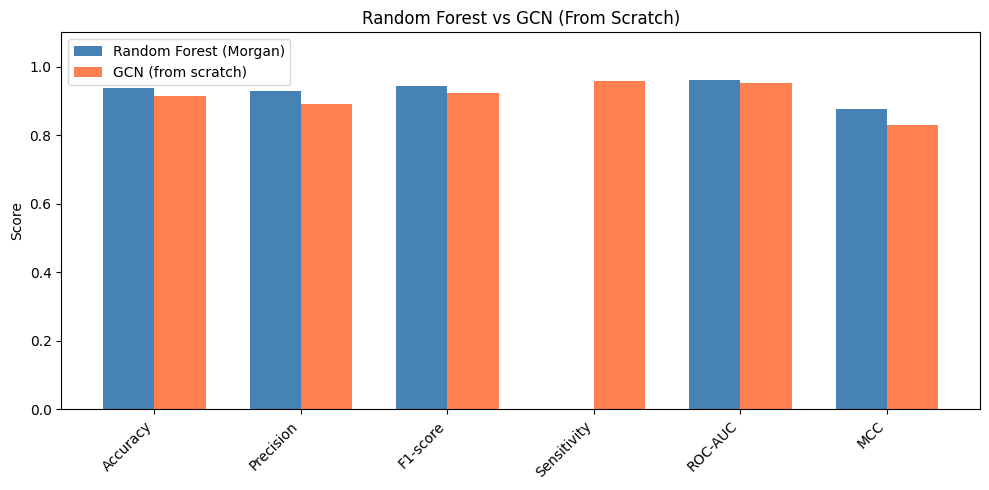

,Model,Accuracy,Precision,F1-score,MCC,Sensitivity (Recall),ROC-AUC,Sensitivity
0,RF (Morgan) - Part 6,0.938,0.930,0.943,0.876,0.957,0.960,NaN
1,Soft Voting - Part 6,0.922,0.928,0.928,0.844,0.928,0.960,NaN
2,GCN (scratch) - Part 9,0.915,0.892,0.923,0.830,NaN,0.952,0.957


In [30]:
rows = []
try:
    rf = pd.read_csv('Part_6/performance_morgan_tuned.csv')
    r = rf[rf['Model'] == 'RandomForestClassifier'].iloc[0].to_dict()
    r['Model'] = 'RF (Morgan) - Part 6'; rows.append(r)
except: pass
try:
    sv = pd.read_csv('Part_6/performance_morgan_tuned.csv')
    r = sv[sv['Model'] == 'Soft Voting'].iloc[0].to_dict()
    r['Model'] = 'Soft Voting - Part 6'; rows.append(r)
except: pass
r = test_results.iloc[0].to_dict(); r['Model'] = 'GCN (scratch) - Part 9'; rows.append(r)

comparison = pd.DataFrame(rows).round(3)
comparison.to_csv('comparison_gnn_vs_ml.csv', index=False)

metrics_to_plot = ['Accuracy', 'Precision', 'F1-score', 'Sensitivity', 'ROC-AUC', 'MCC']
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metrics_to_plot))
w = 0.35
if len(rows) >= 2:
    rf_vals = comparison[comparison['Model'].str.contains('RF')][metrics_to_plot].values.flatten()
    gnn_vals = comparison[comparison['Model'].str.contains('GCN')][metrics_to_plot].values.flatten()
    ax.bar(x - w/2, rf_vals, w, label='Random Forest (Morgan)', color='steelblue')
    ax.bar(x + w/2, gnn_vals, w, label='GCN (from scratch)', color='coral')
    ax.legend()
ax.set_xticks(x); ax.set_xticklabels(metrics_to_plot, rotation=45, ha='right')
ax.set_ylabel('Score'); ax.set_title('Random Forest vs GCN (From Scratch)')
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('comparison_gnn_vs_ml.png', dpi=300, bbox_inches='tight')
plt.show()
comparison

In [ ]:
print("\n=== Part 9 Complete ===")
print("Outputs saved to Part_9/")